# Système de recommandation agricole - Modélisation

## Librairies nécessaires

In [1]:
# Import de base
import pandas as pd
import numpy as np
import sys,os, joblib, shap
import matplotlib.pyplot as plt
import logging
sys.path.append(os.path.abspath(".."))

# Import scikit learn
from sklearn.model_selection import (train_test_split, KFold, cross_validate, GridSearchCV)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor

# Import des autres modèles testés
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings("ignore", message="Hint: Inferred schema contains integer")
warnings.filterwarnings("ignore", message="Saving scikit-learn models")

# Import mlflow
import mlflow
mlflow.set_tracking_uri("file://" + os.path.abspath("../mlruns"))
from mlflow.tracking import MlflowClient
from mlflow.models.signature import infer_signature
# Warning pickle/sklearn de MLflow
logging.getLogger("mlflow.sklearn").setLevel(logging.ERROR)
# Import du projet
from scripts.preprocessing_pipeline import (
    separation_X_y,
    preparation_pipeline,
    cross_validation,
    train_predict
)

/Users/florianschorer/Library/Caches/pypoetry/virtualenvs/systeme-recommandation-agricole-5e-JMIdX-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Comparaison modèle sans optimisation sur le fichier consolidé

In [5]:
def mlflow_tracking_model(model, model_name, tags, projet_description):
    # =====================
    # Configuration MLflow
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("Predictions_Agritech_Answers")

    reg_name = "Forecaster_Global_Baseline"
    mlflow.sklearn.autolog(log_models=False, log_datasets=False, silent=True)

    # =======================
    # Chargement des données
    # Dataset préparé mais non encodé
    df = pd.read_csv("../data/processed/yield_df_final_conso.csv")

    with mlflow.start_run(run_name=model_name, tags={
        "Training Info": tags,
        "Algorithm": model.__class__.__name__,
        "mlflow.note.content": projet_description
    }) as run:

        X_train, X_test, y_train, y_test, categorical_cols, numeric_cols = separation_X_y(df)

        # Pipeline & Cross-Validation
        pipeline = preparation_pipeline(
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
            model=model
        )

        cv_results = cross_validation(pipeline=pipeline, X_train=X_train, y_train=y_train)

        cv_metrics = {
            "cv_rmse_mean_kg": np.sqrt(-cv_results["test_mse"]).mean() / 10,
            "cv_rmse_std_kg": np.sqrt(-cv_results["test_mse"]).std() / 10,
            "cv_mae_mean_kg": (-cv_results["test_mae"]).mean() / 10,
            "cv_mae_std_kg": (-cv_results["test_mae"]).std() / 10,
            "cv_mape_mean": (-cv_results["test_mape"]).mean(),
            "cv_mape_std": (-cv_results["test_mape"]).std(),
            "cv_r2_mean": cv_results["test_r2"].mean(),
            "cv_r2_std": cv_results["test_r2"].std()
            }
        mlflow.log_metrics(cv_metrics)

        # Entraînement final
        pipeline.fit(X_train, y_train)

        # Prédictions test
        y_pred = pipeline.predict(X_test)

        prices_fao = {
            "cassava": 270, "maize": 260, "plantains_and_others": 480, "potatoes": 330,
            "rice": 360, "sorghum": 230, "soybean": 400, "sweet_potatoes": 420,
            "wheat": 200, "yams": 890, "barley": 220
        }

        results_df = pd.DataFrame({
            "actual": y_test,
            "pred": y_pred,
            "abs_error": np.abs(y_test - y_pred)
        }, index=X_test.index)

        # Avec OneHotEncoder, on récupère directement la culture brute
        results_df["crop"] = (
            X_test.loc[results_df.index, "item"]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        mae_by_item = (
            results_df.groupby("crop")["abs_error"]
            .mean()
            .sort_values()
        )

        mlflow.log_metrics({
            f"test_mae_{crop}_kg": float(mae / 10)
            for crop, mae in mae_by_item.items()
            })

        def calculate_monetary_error(row):
            price = prices_fao.get(row["crop"], 250)
            return (row["abs_error"] / 10000) * price

        results_df["error_cost_usd_ha"] = results_df.apply(calculate_monetary_error, axis=1)

        mean_economic_error = results_df["error_cost_usd_ha"].mean()
        rmse_hg = np.sqrt(mean_squared_error(y_test, y_pred))
        mae_hg = mean_absolute_error(y_test, y_pred)
        test_metrics = {
            "test_rmse_kg": rmse_hg / 10,
            "test_mae_kg": mae_hg / 10,
            "test_mape": mean_absolute_percentage_error(y_test, y_pred),
            "test_r2": r2_score(y_test, y_pred),
            "economic_error_usd_ha": mean_economic_error
        }
        mlflow.log_metrics(test_metrics)

        signature = infer_signature(X_test, y_pred)
        model_info = mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            signature=signature,
            registered_model_name=reg_name
        )

        client = MlflowClient()
        mv = model_info.registered_model_version

        full_description = (
            f"**Modèle :** {model_name}\n"
            f"**Note :** {projet_description}\n\n"
            f"**Scores CV (Moyenne ± Écart-type) :**\n"
            f"- CV R2: {cv_metrics['cv_r2_mean']:.4f} (± {cv_metrics['cv_r2_std']:.4f})\n"
            f"- CV RMSE: {cv_metrics['cv_rmse_mean_kg']:.2f} (± {cv_metrics['cv_rmse_std_kg']:.2f})\n\n"
            f"**Scores Test :**\n"
            f"- Test R2: {test_metrics['test_r2']:.4f}\n"
            f"- Test economic_error_usd_ha: {test_metrics['economic_error_usd_ha']:.4f}\n"
        )

        client.update_model_version(name=reg_name, version=mv, description=full_description)
        client.set_model_version_tag(reg_name, mv, "Algo", model.__class__.__name__)
        client.set_model_version_tag(reg_name, mv, "CV_R2", round(cv_metrics["cv_r2_mean"], 4))
        client.set_model_version_tag(reg_name, mv, "CV_Std", round(cv_metrics["cv_r2_std"], 4))
        

        print(f"\nVersion {mv} enregistrée.")
        print("\n=== Résultats métriques ===")
        print(f"CV RMSE : {cv_metrics['cv_rmse_mean_kg']:.4f} (± {cv_metrics['cv_rmse_std_kg']:.2f})")
        print(f"CV MAE  : {cv_metrics['cv_mae_mean_kg']:.4f} (± {cv_metrics['cv_mae_std_kg']:.4f})")
        print(f"CV R2   : {cv_metrics['cv_r2_mean']:.4f} (± {cv_metrics['cv_r2_std']:.4f})")
        print(f"Test RMSE : {test_metrics['test_rmse_kg']:.4f}")
        print(f"Test R2   : {test_metrics['test_r2']:.4f}")
        print(f"Test MAE  : {test_metrics['test_mae_kg']:.4f}")
        print(f"Test economic_error_usd_ha : {test_metrics['economic_error_usd_ha']:.4f}\n")

In [6]:
# DummyRegressor
model = DummyRegressor()
model_name = "DummyRegressor - Baseline"
tags = "DummyRegressor - Baseline"
projet_description = "Test d'un modèle DummyRegressor pour avoir une base sur laquelle comparer"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-07 15:36:58,932 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 15:36:58,932 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
Successfully registered model 'Forecaster_Global_Baseline'.
2026/04/07 15:37:04 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global_Baseline, version 1



Version 1 enregistrée.

=== Résultats métriques ===
CV RMSE : 7604.3730 (± 187.80)
CV MAE  : 5578.7140 (± 93.2737)
CV R2   : -0.0002 (± 0.0002)
Test RMSE : 7216.6343
Test R2   : -0.0013
Test MAE  : 5378.3028
Test economic_error_usd_ha : 1680.7060

🏃 View run DummyRegressor - Baseline at: http://127.0.0.1:5000/#/experiments/4/runs/d1e6f5986bfb4c40aa56b7123da6d633
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


Created version '1' of model 'Forecaster_Global_Baseline'.


In [7]:
# Modèle de régression linéaire
model = LinearRegression()
model_name = "LinearRegression - Baseline"
tags = "LinearRegression - Baseline"
projet_description = "Test d'un modèle LinearRegression sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-07 15:38:03,973 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 15:38:03,974 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
Registered model 'Forecaster_Global_Baseline' already exists. Creating a new version of this model...
2026/04/07 15:38:09 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global_Baseline, version 2



Version 2 enregistrée.

=== Résultats métriques ===
CV RMSE : 4840.4290 (± 55.16)
CV MAE  : 3233.5153 (± 58.2632)
CV R2   : 0.5943 (± 0.0143)
Test RMSE : 4805.9227
Test R2   : 0.5559
Test MAE  : 3201.1100
Test economic_error_usd_ha : 1033.3629

🏃 View run LinearRegression - Baseline at: http://127.0.0.1:5000/#/experiments/4/runs/eee64351076842b0bcfc3af0fe27a781
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


Created version '2' of model 'Forecaster_Global_Baseline'.


In [8]:
# Modèle de RandomForest
model = RandomForestRegressor(random_state=42)
model_name = "RandomForest - Baseline"
tags = "RandomForest - Baseline"
projet_description = "Test d'un modèle Random Forest sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-07 15:38:38,183 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 15:38:38,183 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
Registered model 'Forecaster_Global_Baseline' already exists. Creating a new version of this model...
2026/04/07 15:40:51 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global_Baseline, version 3



Version 3 enregistrée.

=== Résultats métriques ===
CV RMSE : 1893.0226 (± 45.34)
CV MAE  : 894.9234 (± 4.1971)
CV R2   : 0.9378 (± 0.0051)
Test RMSE : 1729.6763
Test R2   : 0.9425
Test MAE  : 796.4869
Test economic_error_usd_ha : 273.6834

🏃 View run RandomForest - Baseline at: http://127.0.0.1:5000/#/experiments/4/runs/8a3eb37807134c82bac082ab20858df1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


Created version '3' of model 'Forecaster_Global_Baseline'.


In [9]:
# Modèle de XGBoost
model = xgb.XGBRegressor(random_state=42)
model_name = "XGBRegressor - Baseline"
tags = "XGBRegressor - Baseline"
projet_description = "Test d'un modèle XGBRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-07 15:41:31,287 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 15:41:31,288 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
Registered model 'Forecaster_Global_Baseline' already exists. Creating a new version of this model...
2026/04/07 15:41:35 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global_Baseline, version 4



Version 4 enregistrée.

=== Résultats métriques ===
CV RMSE : 2152.0037 (± 71.11)
CV MAE  : 1292.0533 (± 24.5055)
CV R2   : 0.9195 (± 0.0082)
Test RMSE : 2040.8158
Test R2   : 0.9199
Test MAE  : 1226.2530
Test economic_error_usd_ha : 406.6547

🏃 View run XGBRegressor - Baseline at: http://127.0.0.1:5000/#/experiments/4/runs/774a0c83a35d478bb00f766fd73cab4c
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


Created version '4' of model 'Forecaster_Global_Baseline'.


In [10]:
# Modèle de LightGBM
model = lgb.LGBMRegressor(random_state=42, verbose=-1)
model_name = "LGBMRegressor - Baseline"
tags = "LGBMRegressor - Baseline"
projet_description = "Test d'un modèle LGBMRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-07 15:41:41,761 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 15:41:41,762 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
Registered model 'Forecaster_Global_Baseline' already exists. Creating a new version of this model...
2026/04/07 15:41:48 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global_Baseline, version 5



Version 5 enregistrée.

=== Résultats métriques ===
CV RMSE : 2689.7368 (± 50.00)
CV MAE  : 1708.5830 (± 30.6892)
CV R2   : 0.8745 (± 0.0095)
Test RMSE : 2679.5389
Test R2   : 0.8620
Test MAE  : 1675.0012
Test economic_error_usd_ha : 551.5749

🏃 View run LGBMRegressor - Baseline at: http://127.0.0.1:5000/#/experiments/4/runs/93c95215891f400f80010e94acc4adcb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


Created version '5' of model 'Forecaster_Global_Baseline'.


- Sur ces premiers tests, le modèle qui s'en sort le mieux sur l'ensemble des métriques (performance et métier) c'est celui de Random Forest.
- Les résultats de XGBoost et LightGBM sont exploitables pour essayer d'améliorer leur performance.
- Par contre le modèle de régression linéaire est trop loin en terme de performance. Au vu de la distribution de notre varibale cible, cela n'est pas étonnant.

# Comparaison modèle sans optimisation sur le fichier enrichi

In [11]:
def mlflow_tracking_model(model, model_name, tags, projet_description):
    # =====================
    # Configuration MLflow
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("Predictions_Agritech_Answers")

    reg_name = "Forecaster_Global_Baseline"
    mlflow.sklearn.autolog(log_models=False, log_datasets=False, silent=True)

    # =======================
    # Chargement des données
    # Dataset préparé mais NON encodé
    df = pd.read_csv("../data/processed/yield_df_enriched_conso.csv")

    with mlflow.start_run(run_name=model_name, tags={
        "Training Info": tags,
        "Algorithm": model.__class__.__name__,
        "mlflow.note.content": projet_description
    }) as run:

        X_train, X_test, y_train, y_test, categorical_cols, numeric_cols = separation_X_y(df)

        # Pipeline & Cross-Validation
        pipeline = preparation_pipeline(
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
            model=model
        )

        cv_results = cross_validation(pipeline=pipeline, X_train=X_train, y_train=y_train)

        cv_metrics = {
            "cv_rmse_mean_kg": np.sqrt(-cv_results["test_mse"]).mean() / 10,
            "cv_rmse_std_kg": np.sqrt(-cv_results["test_mse"]).std() / 10,
            "cv_mae_mean_kg": (-cv_results["test_mae"]).mean() / 10,
            "cv_mae_std_kg": (-cv_results["test_mae"]).std() / 10,
            "cv_mape_mean": (-cv_results["test_mape"]).mean(),
            "cv_mape_std": (-cv_results["test_mape"]).std(),
            "cv_r2_mean": cv_results["test_r2"].mean(),
            "cv_r2_std": cv_results["test_r2"].std()
            }
        mlflow.log_metrics(cv_metrics)

        # Entraînement final
        pipeline.fit(X_train, y_train)

        # Prédictions test
        y_pred = pipeline.predict(X_test)

        prices_fao = {
            "cassava": 270, "maize": 260, "plantains_and_others": 480, "potatoes": 330,
            "rice": 360, "sorghum": 230, "soybean": 400, "sweet_potatoes": 420,
            "wheat": 200, "yams": 890, "barley": 220
        }

        results_df = pd.DataFrame({
            "actual": y_test,
            "pred": y_pred,
            "abs_error": np.abs(y_test - y_pred)
        }, index=X_test.index)

        # Avec OneHotEncoder, on récupère directement la culture brute
        results_df["crop"] = (
            X_test.loc[results_df.index, "item"]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        mae_by_item = (
            results_df.groupby("crop")["abs_error"]
            .mean()
            .sort_values()
        )

        mlflow.log_metrics({
            f"test_mae_{crop}_kg": float(mae / 10)
            for crop, mae in mae_by_item.items()
            })

        def calculate_monetary_error(row):
            price = prices_fao.get(row["crop"], 250)
            return (row["abs_error"] / 10000) * price

        results_df["error_cost_usd_ha"] = results_df.apply(calculate_monetary_error, axis=1)

        mean_economic_error = results_df["error_cost_usd_ha"].mean()
        rmse_hg = np.sqrt(mean_squared_error(y_test, y_pred))
        mae_hg = mean_absolute_error(y_test, y_pred)
        test_metrics = {
            "test_rmse_kg": rmse_hg / 10,
            "test_mae_kg": mae_hg / 10,
            "test_mape": mean_absolute_percentage_error(y_test, y_pred),
            "test_r2": r2_score(y_test, y_pred),
            "economic_error_usd_ha": mean_economic_error
        }
        mlflow.log_metrics(test_metrics)

        signature = infer_signature(X_test, y_pred)
        model_info = mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="model",
            signature=signature,
            registered_model_name=reg_name
        )

        client = MlflowClient()
        mv = model_info.registered_model_version

        full_description = (
            f"**Modèle :** {model_name}\n"
            f"**Note :** {projet_description}\n\n"
            f"**Scores CV (Moyenne ± Écart-type) :**\n"
            f"- CV R2: {cv_metrics['cv_r2_mean']:.4f} (± {cv_metrics['cv_r2_std']:.4f})\n"
            f"- CV RMSE: {cv_metrics['cv_rmse_mean_kg']:.2f} (± {cv_metrics['cv_rmse_std_kg']:.2f})\n\n"
            f"**Scores Test :**\n"
            f"- Test R2: {test_metrics['test_r2']:.4f}\n"
            f"- Test economic_error_usd_ha: {test_metrics['economic_error_usd_ha']:.4f}\n"
        )

        client.update_model_version(name=reg_name, version=mv, description=full_description)
        client.set_model_version_tag(reg_name, mv, "Algo", model.__class__.__name__)
        client.set_model_version_tag(reg_name, mv, "CV_R2", round(cv_metrics["cv_r2_mean"], 4))
        client.set_model_version_tag(reg_name, mv, "CV_Std", round(cv_metrics["cv_r2_std"], 4))
        

        print(f"\nVersion {mv} enregistrée.")
        print("\n=== Résultats métriques ===")
        print(f"CV RMSE : {cv_metrics['cv_rmse_mean_kg']:.4f} (± {cv_metrics['cv_rmse_std_kg']:.2f})")
        print(f"CV MAE  : {cv_metrics['cv_mae_mean_kg']:.4f} (± {cv_metrics['cv_mae_std_kg']:.4f})")
        print(f"CV R2   : {cv_metrics['cv_r2_mean']:.4f} (± {cv_metrics['cv_r2_std']:.4f})")
        print(f"Test RMSE : {test_metrics['test_rmse_kg']:.4f}")
        print(f"Test R2   : {test_metrics['test_r2']:.4f}")
        print(f"Test MAE  : {test_metrics['test_mae_kg']:.4f}")
        print(f"Test economic_error_usd_ha : {test_metrics['economic_error_usd_ha']:.4f}\n")

In [12]:
# DummyRegressor
model = DummyRegressor()
model_name = "DummyRegressor - Baseline - fichier enrichi"
tags = "DummyRegressor - Baseline - fichier enrichi"
projet_description = "Test d'un modèle DummyRegressor pour avoir une base sur laquelle comparer"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-07 15:42:42,901 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 15:42:42,901 - INFO - Colonnes catégorielles : ['region', 'item', 'fertilizer_used', 'irrigation_used', 'weather_condition', 'soil_type', 'is_drought']
Registered model 'Forecaster_Global_Baseline' already exists. Creating a new version of this model...
2026/04/07 15:42:46 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global_Baseline, version 6



Version 6 enregistrée.

=== Résultats métriques ===
CV RMSE : 7604.3730 (± 187.80)
CV MAE  : 5578.7140 (± 93.2737)
CV R2   : -0.0002 (± 0.0002)
Test RMSE : 7216.6343
Test R2   : -0.0013
Test MAE  : 5378.3028
Test economic_error_usd_ha : 1680.7060

🏃 View run DummyRegressor - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/4/runs/178aea10e61c401d888c789568531136
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


Created version '6' of model 'Forecaster_Global_Baseline'.


In [13]:
# Modèle de régression linéaire
model = LinearRegression()
model_name = "LinearRegression - Baseline - fichier enrichi"
tags = "LinearRegression - Baseline - fichier enrichi"
projet_description = "Test d'un modèle LinearRegression sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-07 15:42:51,270 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 15:42:51,271 - INFO - Colonnes catégorielles : ['region', 'item', 'fertilizer_used', 'irrigation_used', 'weather_condition', 'soil_type', 'is_drought']
Registered model 'Forecaster_Global_Baseline' already exists. Creating a new version of this model...
2026/04/07 15:42:54 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global_Baseline, version 7



Version 7 enregistrée.

=== Résultats métriques ===
CV RMSE : 4841.7110 (± 54.37)
CV MAE  : 3234.7068 (± 57.8159)
CV R2   : 0.5941 (± 0.0143)
Test RMSE : 4807.8225
Test R2   : 0.5556
Test MAE  : 3202.9833
Test economic_error_usd_ha : 1034.2202

🏃 View run LinearRegression - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/4/runs/6458e0a9765148a7ba0f2cd9beb671ef
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


Created version '7' of model 'Forecaster_Global_Baseline'.


In [14]:
# Modèle de RandomForest
model = RandomForestRegressor(random_state=42)
model_name = "RandomForest - Baseline - fichier enrichi"
tags = "RandomForest - Baseline"
projet_description = "Test d'un modèle Random Forest sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)


2026-04-07 15:42:59,150 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 15:42:59,150 - INFO - Colonnes catégorielles : ['region', 'item', 'fertilizer_used', 'irrigation_used', 'weather_condition', 'soil_type', 'is_drought']
Registered model 'Forecaster_Global_Baseline' already exists. Creating a new version of this model...
2026/04/07 15:46:28 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global_Baseline, version 8



Version 8 enregistrée.

=== Résultats métriques ===
CV RMSE : 1926.1649 (± 66.57)
CV MAE  : 950.5381 (± 12.3603)
CV R2   : 0.9355 (± 0.0065)
Test RMSE : 1748.9721
Test R2   : 0.9412
Test MAE  : 856.2829
Test economic_error_usd_ha : 291.8239

🏃 View run RandomForest - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/4/runs/08aad55c424d4dd2b6163cac0b7cedf9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


Created version '8' of model 'Forecaster_Global_Baseline'.


In [15]:
# Modèle de XGBoost
model = xgb.XGBRegressor(random_state=42)
model_name = "XGBRegressor - Baseline - fichier enrichi"
tags = "XGBRegressor - Baseline - fichier enrichi"
projet_description = "Test d'un modèle XGBRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-07 15:46:32,856 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 15:46:32,856 - INFO - Colonnes catégorielles : ['region', 'item', 'fertilizer_used', 'irrigation_used', 'weather_condition', 'soil_type', 'is_drought']
Registered model 'Forecaster_Global_Baseline' already exists. Creating a new version of this model...
2026/04/07 15:46:37 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global_Baseline, version 9
Created version '9' of model 'Forecaster_Global_Baseline'.



Version 9 enregistrée.

=== Résultats métriques ===
CV RMSE : 2179.0641 (± 44.71)
CV MAE  : 1320.7450 (± 22.2847)
CV R2   : 0.9175 (± 0.0072)
Test RMSE : 2017.5085
Test R2   : 0.9217
Test MAE  : 1249.1880
Test economic_error_usd_ha : 413.5231

🏃 View run XGBRegressor - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/4/runs/21f13f483e264226a7259d4b673a2d74
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


In [16]:
# Modèle de LightGBM
model = lgb.LGBMRegressor(random_state=42, verbose=-1)
model_name = "LGBMRegressor - Baseline - fichier enrichi"
tags = "LGBMRegressor - Baselzine - fichier enrichi"
projet_description = "Test d'un modèle LGBMRegressor sans optimisation"
mlflow_tracking_model(model, model_name, tags, projet_description)

2026-04-07 15:47:27,795 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 15:47:27,796 - INFO - Colonnes catégorielles : ['region', 'item', 'fertilizer_used', 'irrigation_used', 'weather_condition', 'soil_type', 'is_drought']
Registered model 'Forecaster_Global_Baseline' already exists. Creating a new version of this model...
2026/04/07 15:47:35 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global_Baseline, version 10



Version 10 enregistrée.

=== Résultats métriques ===
CV RMSE : 2709.1046 (± 52.11)
CV MAE  : 1715.8439 (± 30.4070)
CV R2   : 0.8726 (± 0.0101)
Test RMSE : 2677.7113
Test R2   : 0.8621
Test MAE  : 1672.1599
Test economic_error_usd_ha : 553.9541

🏃 View run LGBMRegressor - Baseline - fichier enrichi at: http://127.0.0.1:5000/#/experiments/4/runs/1069c6718d3c432d882d703299a99466
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


Created version '10' of model 'Forecaster_Global_Baseline'.


# Optimisation des hyperparamètres sur RandomForest / XGBoost & LightGBM

A l'aide de gridsearchCV, on va essayer ici de trouver les meilleurs hyperparamètres pour chacun des modèles

In [17]:
def mlflow_tracking_gridsearch(model, model_name, param_grid, tags, projet_description):
    # =====================
    # Configuration MLflow
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment("Predictions_Agritech_Answers")

    reg_name = "Forecaster_Global_GridSearch"
    mlflow.sklearn.autolog(log_models=False, log_datasets=False, silent=True, max_tuning_runs=0)

    # =======================
    # Chargement des données
    df = pd.read_csv("../data/processed/yield_df_final_conso.csv")

    with mlflow.start_run(run_name=model_name, tags={
        "Training Info": tags,
        "Algorithm": model.__class__.__name__,
        "mlflow.note.content": projet_description
    }) as run:

        mlflow.set_tag("target_raw_unit", "hg/ha")
        mlflow.set_tag("logged_metric_unit", "kg/ha")
        mlflow.set_tag("economic_metric_unit", "usd/ha")

        X_train, X_test, y_train, y_test, categorical_cols, numeric_cols = separation_X_y(df)

        # Pipeline & GridSearch
        pipeline = preparation_pipeline(
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
            model=model
        )

        cv = KFold(n_splits=5, shuffle=True, random_state=42)

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring="r2",
            n_jobs=-1,
            cv=cv,
            refit=True,
            error_score="raise"
        )

        grid_search.fit(X_train, y_train)

        best_index = grid_search.best_index_

        cv_metrics = {
            "best_cv_r2_mean": grid_search.best_score_,
            "best_cv_r2_std": grid_search.cv_results_["std_test_score"][best_index]
        }

        mlflow.log_params(grid_search.best_params_)
        mlflow.log_metrics(cv_metrics)

        # Entraînement final déjà fait par refit=True
        best_pipeline = grid_search.best_estimator_

        # Prédictions test
        y_pred = best_pipeline.predict(X_test)

        prices_fao = {
            "cassava": 270, "maize": 260, "plantains_and_others": 480, "potatoes": 330,
            "rice": 360, "sorghum": 230, "soybean": 400, "sweet_potatoes": 420,
            "wheat": 200, "yams": 890, "barley": 220
        }

        results_df = pd.DataFrame({
            "actual": y_test,
            "pred": y_pred,
            "abs_error": np.abs(y_test - y_pred)  # en hg/ha
        }, index=X_test.index)

        results_df["crop"] = (
            X_test.loc[results_df.index, "item"]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        mae_by_item = (
            results_df.groupby("crop")["abs_error"]
            .mean()
            .sort_values()
        )

        # Logging par culture en kg/ha
        mlflow.log_metrics({
            f"test_mae_{crop}_kg_ha": float(mae / 10)
            for crop, mae in mae_by_item.items()
        })

        def calculate_monetary_error(row):
            price = prices_fao.get(row["crop"], 250)
            return (row["abs_error"] / 10000) * price

        results_df["error_cost_usd_ha"] = results_df.apply(calculate_monetary_error, axis=1)
        mean_economic_error = results_df["error_cost_usd_ha"].mean()

        rmse_hg = np.sqrt(mean_squared_error(y_test, y_pred))
        mae_hg = mean_absolute_error(y_test, y_pred)

        test_metrics = {
            "test_rmse_kg_ha": rmse_hg / 10,
            "test_mae_kg_ha": mae_hg / 10,
            "test_mape": mean_absolute_percentage_error(y_test, y_pred),
            "test_r2": r2_score(y_test, y_pred),
            "economic_error_usd_ha": mean_economic_error
        }
        mlflow.log_metrics(test_metrics)

        signature = infer_signature(X_test, y_pred)

        model_info = mlflow.sklearn.log_model(
            sk_model=best_pipeline,
            name="model",
            signature=signature,
            registered_model_name=reg_name
        )

        client = MlflowClient()
        mv = model_info.registered_model_version

        full_description = (
            f"**Modèle Optimisé :** {model_name}\n"
            f"**Note :** {projet_description}\n\n"
            f"**Scores CV :**\n"
            f"- Best CV R2: {cv_metrics['best_cv_r2_mean']:.4f} "
            f"(± {cv_metrics['best_cv_r2_std']:.4f})\n\n"
            f"**Scores Test :**\n"
            f"- Test R2: {test_metrics['test_r2']:.4f}\n"
            f"- Test RMSE (kg/ha): {test_metrics['test_rmse_kg_ha']:.2f}\n"
            f"- Test MAE (kg/ha): {test_metrics['test_mae_kg_ha']:.2f}\n"
            f"- Test MAPE: {test_metrics['test_mape']:.2%}\n"
            f"- Test economic_error_usd_ha: {test_metrics['economic_error_usd_ha']:.4f}\n"
        )

        client.update_model_version(name=reg_name, version=mv, description=full_description)
        client.set_model_version_tag(reg_name, mv, "Algo", model.__class__.__name__)
        client.set_model_version_tag(reg_name, mv, "Best_CV_R2", round(cv_metrics["best_cv_r2_mean"], 4))
        client.set_model_version_tag(reg_name, mv, "Best_CV_Std", round(cv_metrics["best_cv_r2_std"], 4))
        client.set_model_version_tag(reg_name, mv, "Test_RMSE_kg_ha", round(test_metrics["test_rmse_kg_ha"], 2))
        client.set_model_version_tag(reg_name, mv, "Test_MAE_kg_ha", round(test_metrics["test_mae_kg_ha"], 2))

        print(f"\nVersion {mv} enregistrée.")
        print("\n=== Résultats métriques ===")
        print(f"Best CV R2         : {cv_metrics['best_cv_r2_mean']:.4f} (± {cv_metrics['best_cv_r2_std']:.4f})")
        print(f"Test RMSE (kg/ha)  : {test_metrics['test_rmse_kg_ha']:.4f}")
        print(f"Test R2            : {test_metrics['test_r2']:.4f}")
        print(f"Test MAE (kg/ha)   : {test_metrics['test_mae_kg_ha']:.4f}")
        print(f"Test MAPE          : {test_metrics['test_mape']:.2%}")
        print(f"Test economic_error_usd_ha : {test_metrics['economic_error_usd_ha']:.4f}\n")

        return {
            "best_pipeline": best_pipeline,
            "best_params": grid_search.best_params_,
            "test_metrics": test_metrics,
            "X_test": X_test,
            "y_test": y_test
        }

In [18]:
 # Modèle de RandomForest
model = RandomForestRegressor(random_state=42, n_jobs=1)
model_name = "RandomForest - GridSearchCV"
param_grid = {
    'model__n_estimators': [200],
    'model__max_depth': [25],
    'model__min_samples_split': [2],
    'model__max_features': [0.7]
}
tags = "RandomForest - GridSearchCV"
projet_description = "L'objectif est de trouver les meilleurs paramètres possibles pour ce modèle"
results = mlflow_tracking_gridsearch(model, model_name,param_grid, tags, projet_description)

best_pipeline = results["best_pipeline"]

# Sauvegarde explicite du meilleur pipeline pour SHAP plus tard
joblib.dump(best_pipeline, "../model/randomforest_best_pipeline.joblib")

print("Pipeline sauvegardé : ../model/randomforest_best_pipeline.joblib")
print("Best params :", results["best_params"])

2026-04-07 15:50:11,479 - INFO - Colonnes numériques : ['avg_temp', 'rainfall_mm', 'pesticides_tonnes', 'input_imbalance', 'thermal_stress', 'years_from_now']
2026-04-07 15:50:11,480 - INFO - Colonnes catégorielles : ['region', 'item', 'is_drought']
Successfully registered model 'Forecaster_Global_GridSearch'.
2026/04/07 15:53:09 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Forecaster_Global_GridSearch, version 1
Created version '1' of model 'Forecaster_Global_GridSearch'.



Version 1 enregistrée.

=== Résultats métriques ===
Best CV R2         : 0.9397 (± 0.0055)
Test RMSE (kg/ha)  : 1712.4748
Test R2            : 0.9436
Test MAE (kg/ha)   : 804.5366
Test MAPE          : 17.75%
Test economic_error_usd_ha : 274.4312

🏃 View run RandomForest - GridSearchCV at: http://127.0.0.1:5000/#/experiments/4/runs/7a7c5b340867450893afdb12433b6fd9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4
Pipeline sauvegardé : ../model/randomforest_best_pipeline.joblib
Best params : {'model__max_depth': 25, 'model__max_features': 0.7, 'model__min_samples_split': 2, 'model__n_estimators': 200}


# SHAP Values

In [2]:
import os
import joblib
import shap
import pandas as pd

ARTIFACT_DIR = "../model/shap_randomforest_sample"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

PIPELINE_PATH = "../model/randomforest_best_pipeline.joblib"
DATA_PATH = "../data/processed/yield_df_final_conso.csv"

SAMPLE_SIZE = 300
RANDOM_STATE = 42

# Chargement pipeline + données
pipeline = joblib.load(PIPELINE_PATH)
df = pd.read_csv(DATA_PATH)

X_full = df.drop(columns=["yield"]).copy()

# Préprocessing
preprocessor = pipeline.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()

X_full_transformed = preprocessor.transform(X_full)

if hasattr(X_full_transformed, "toarray"):
    X_full_transformed = X_full_transformed.toarray()

X_full_transformed = pd.DataFrame(
    X_full_transformed,
    columns=feature_names,
    index=X_full.index
)

# Échantillon
sample_size = min(SAMPLE_SIZE, len(X_full_transformed))
X_shap = X_full_transformed.sample(n=sample_size, random_state=RANDOM_STATE)

# SHAP
model = pipeline.named_steps["model"]
explainer = shap.TreeExplainer(
    model,
    feature_perturbation="tree_path_dependent"
)

shap_values = explainer.shap_values(
    X_shap.values,
    check_additivity=False
)

# Sauvegarde
ARTIFACT_DIR = "../model/shap_randomforest_sample"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

joblib.dump(X_shap, os.path.join(ARTIFACT_DIR, "X_shap_sample.joblib"))
joblib.dump(shap_values, os.path.join(ARTIFACT_DIR, "shap_values_sample.joblib"))
joblib.dump(explainer.expected_value, os.path.join(ARTIFACT_DIR, "expected_value.joblib"))

print("Artefacts SHAP sauvegardés dans :", ARTIFACT_DIR)
print("Shape X_shap :", X_shap.shape)

Artefacts SHAP sauvegardés dans : ../model/shap_randomforest_sample
Shape X_shap : (300, 35)


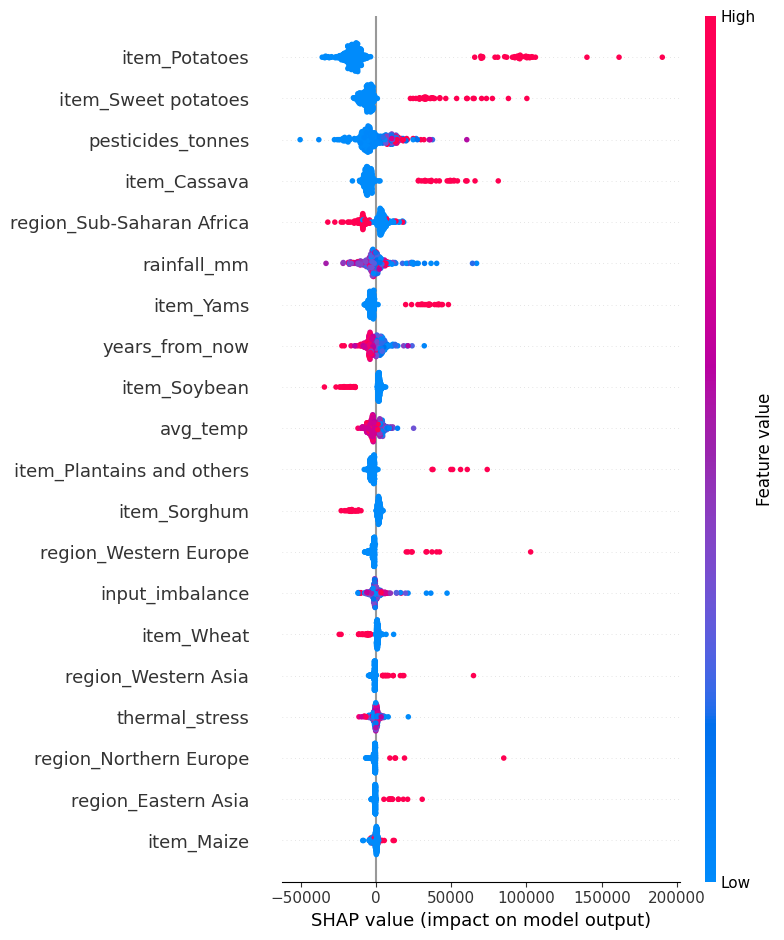

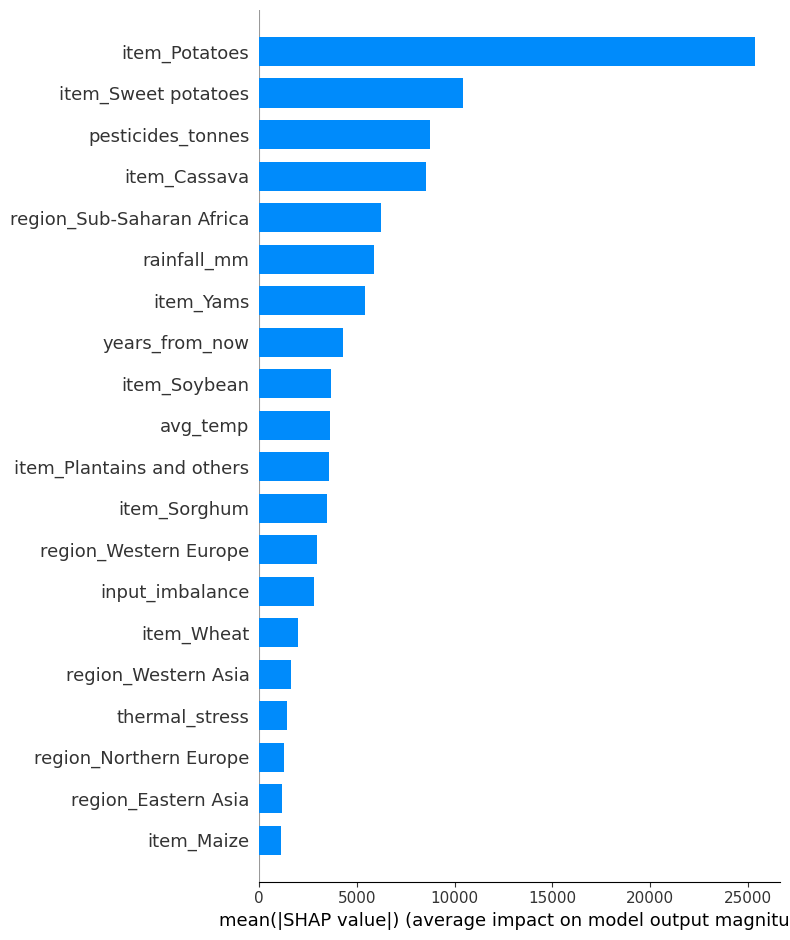

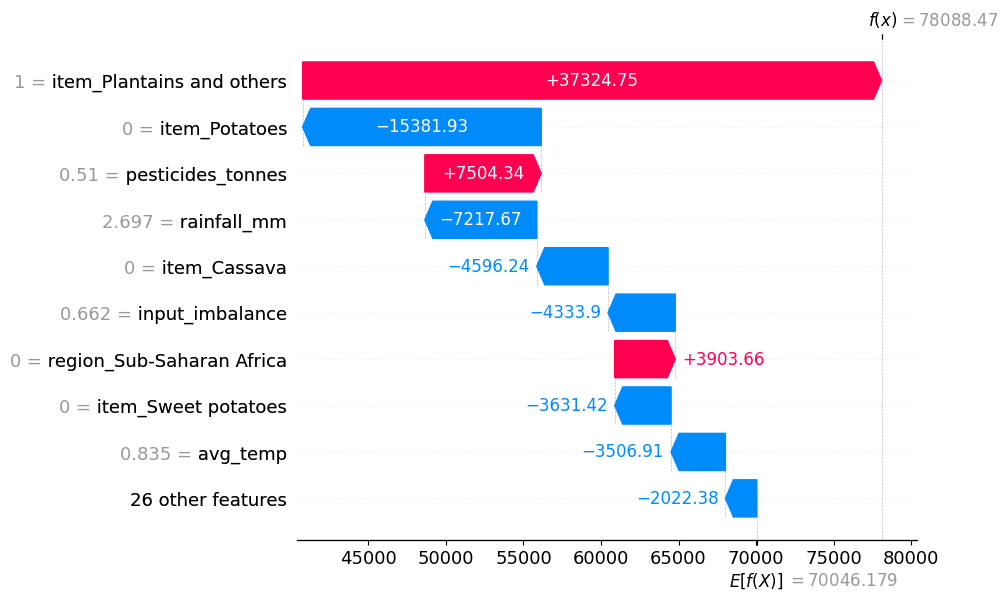

In [3]:
ARTIFACT_DIR = "../model/shap_randomforest_sample"

X_shap = joblib.load(os.path.join(ARTIFACT_DIR, "X_shap_sample.joblib"))
shap_values = joblib.load(os.path.join(ARTIFACT_DIR, "shap_values_sample.joblib"))
expected_value = joblib.load(os.path.join(ARTIFACT_DIR, "expected_value.joblib"))

# Noms plus lisibles
X_plot = X_shap.copy()
X_plot.columns = [
    col.replace("num__", "").replace("cat__", "")
    for col in X_plot.columns
]

# 1. Importance globale
shap.summary_plot(shap_values, X_plot)

# 2. Importance bar
shap.summary_plot(shap_values, X_plot, plot_type="bar")

base_value = expected_value.item() if hasattr(expected_value, "item") else float(expected_value)
# 3. Waterfall sur une observation
idx = 36
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=base_value,
        data=X_plot.iloc[idx],
        feature_names=X_plot.columns
    )
)

# Feature importance


Top 15 features :
                                  feature  importance
0                      cat__item_Potatoes    0.314446
1                  num__pesticides_tonnes    0.095353
2                        num__rainfall_mm    0.085711
3                    num__input_imbalance    0.050120
4              cat__region_Western Europe    0.049183
5                cat__item_Sweet potatoes    0.043271
6                       cat__item_Cassava    0.042040
7                           num__avg_temp    0.037829
8                     num__years_from_now    0.037794
9                     num__thermal_stress    0.031121
10         cat__region_Sub-Saharan Africa    0.027085
11         cat__item_Plantains and others    0.023141
12                         cat__item_Yams    0.021330
13                      cat__item_Sorghum    0.014939
14  cat__region_Australia and New Zealand    0.014577


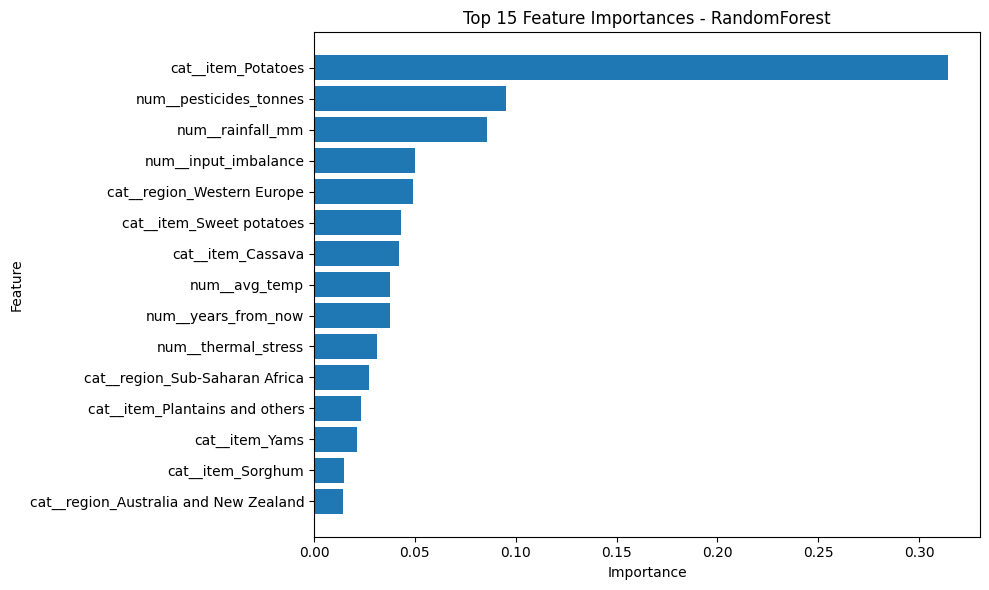


Importance par groupe :
                  group  importance
0                  item    0.493637
1  numeric_climate_tech    0.300134
2                region    0.165708
3                 other    0.040522


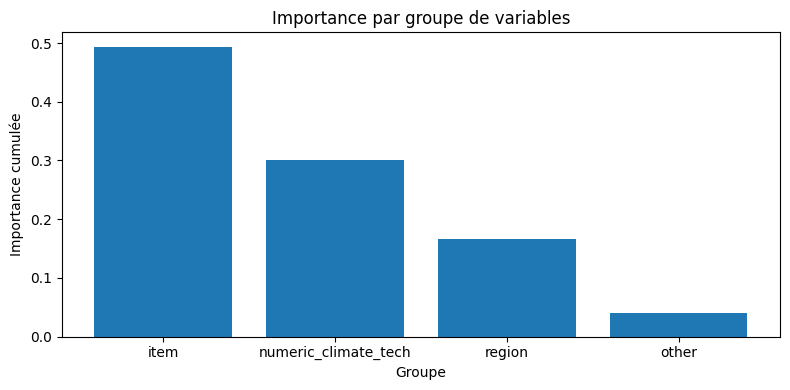

In [19]:
best_pipeline = joblib.load("../model/randomforest_best_pipeline.joblib")
# Extraire le modèle et le préprocesseur du pipeline
rf_model = best_pipeline.named_steps["model"]
preprocessor = best_pipeline.named_steps["preprocessor"]

# Récupérer les noms de variables après transformation
feature_names = preprocessor.get_feature_names_out()

# Récupérer les importances
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\nTop 15 features :")
print(feature_importance_df.head(15))

# Sauvegarder les importances

feature_importance_df.to_csv("../data/processed/feature_importance_random_forest.csv", index=False)

# Visualisation top 15

top_n = 15
top_features = feature_importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 Feature Importances - RandomForest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Regrouper les variables par famille métier

def feature_group(feature_name: str) -> str:

    if "avg_temp" in feature_name or "rainfall_mm" in feature_name \
       or "pesticides_tonnes" in feature_name or "input_imbalance" in feature_name \
       or "thermal_stress" in feature_name:
        return "numeric_climate_tech"
    
    if "region_" in feature_name:
        return "region"
    
    if "item_" in feature_name:
        return "item"
    
    return "other"

feature_importance_df["group"] = feature_importance_df["feature"].apply(feature_group)

group_importance_df = (
    feature_importance_df
    .groupby("group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nImportance par groupe :")
print(group_importance_df)

# Visualisation par groupe

plt.figure(figsize=(8, 4))
plt.bar(group_importance_df["group"], group_importance_df["importance"])
plt.title("Importance par groupe de variables")
plt.xlabel("Groupe")
plt.ylabel("Importance cumulée")
plt.tight_layout()
plt.show()